In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4329.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4223.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4253.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4190.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4354.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4136.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4226.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4214.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4888.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4170.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4323.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4262.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4788.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4657.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4387.jpg
/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4255.jpg
/kaggle/

In [2]:
import tensorflow as tf
import keras_preprocessing
from keras_preprocessing import image
from keras_preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Convolution2D
from keras.layers import Activation
from keras.layers import Dropout
from keras.layers import MaxPool2D
from keras.layers import Flatten

import matplotlib.pyplot as plt                                     
import matplotlib.image as mpimg

In [3]:
import os

base_dir = "../input/cat-and-dog/"
train = "../input/cat-and-dog/training_set/training_set/"
test = "../input/cat-and-dog/test_set/test_set/"

print(os.listdir(train))
print(os.listdir(test))

['dogs', 'cats']
['dogs', 'cats']


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255, zoom_range = 0.2,
                                   rotation_range=40, horizontal_flip= True)

test_datagen = ImageDataGenerator(rescale=1./255)

In [5]:
train_generator = train_datagen.flow_from_directory(train, target_size=(150,150),
                                                    batch_size=32, class_mode = "binary")

test_generator = test_datagen.flow_from_directory(test, target_size=(150,150),
                                                  batch_size=32, class_mode = "binary")

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 2 classes.


In [6]:
# Criteria for model training stops
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('accuracy') > 0.95 and logs.get('val_accuracy') > 0.90):
      print("\nTRAINING STOPPED, THE ACCURACY MODEL IS MORE THAN 90%!")
      self.model.stop_training = True

callbacks = myCallback()

#MODEL
from tensorflow.keras.models import Sequential
model = Sequential()

from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam

model.add(Conv2D(32, (3,3), padding="SAME", activation="relu", input_shape = (150,150,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), padding="SAME", activation="relu", input_shape = (150,150,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), padding="SAME", activation="relu", input_shape = (150,150,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, (3,3), padding="SAME", activation="relu", input_shape = (150,150,3)))
model.add(MaxPooling2D(pool_size=(2,2)))


model.add(Flatten())

model.add(Dense(512, activation="relu"))

model.add(Dense(1, activation="sigmoid"))

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 150, 150, 32)      896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 75, 75, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 75, 75, 64)        18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 37, 37, 64)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 37, 37, 64)        36928     
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 18, 18, 64)        0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 18, 18, 128)       7

In [7]:
#COMPILE MODEL 
model.compile(Adam(lr=0.001), loss = "binary_crossentropy", metrics="accuracy")

In [8]:
#Training models
history=model.fit(train_generator,
          epochs=100,
          validation_data=test_generator,
          callbacks=[callbacks])

Epoch 1/100
251/251 [==============================] - 221s 876ms/step - loss: 0.6943 - accuracy: 0.5222 - val_loss: 0.6570 - val_accuracy: 0.6238
Epoch 2/100
251/251 [==============================] - 212s 842ms/step - loss: 0.6544 - accuracy: 0.6256 - val_loss: 0.6311 - val_accuracy: 0.6644
Epoch 3/100
251/251 [==============================] - 210s 838ms/step - loss: 0.6213 - accuracy: 0.6526 - val_loss: 0.5950 - val_accuracy: 0.6945
Epoch 4/100
251/251 [==============================] - 209s 832ms/step - loss: 0.5806 - accuracy: 0.6898 - val_loss: 0.5332 - val_accuracy: 0.7355
Epoch 5/100
251/251 [==============================] - 208s 829ms/step - loss: 0.5463 - accuracy: 0.7156 - val_loss: 0.5249 - val_accuracy: 0.7449
Epoch 6/100
251/251 [==============================] - 210s 836ms/step - loss: 0.5295 - accuracy: 0.7332 - val_loss: 0.5146 - val_accuracy: 0.7410
Epoch 7/100
251/251 [==============================] - 211s 838ms/step - loss: 0.5068 - accuracy: 0.7478 - val_loss: 0

PLOT ACCURACY TRAIN & TEST

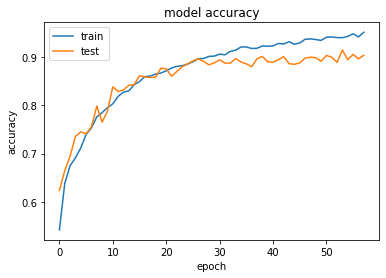

In [9]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

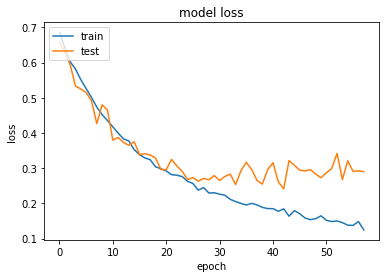

In [10]:
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [11]:
import numpy as np
from keras.preprocessing import image

/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4726.jpg
This is a Dogs


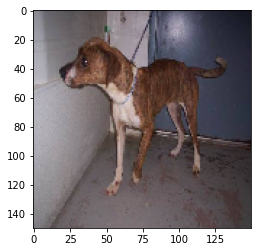

In [12]:
path = '/kaggle/input/cat-and-dog/test_set/test_set/dogs/dog.4726.jpg'
img = image.load_img(path, target_size=(150, 150))
imgplot = plt.imshow(img)
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

images = np.vstack([x])
classes = model.predict(images, batch_size=10)
print(path)
if classes[0][0]==1:
    print('This is a Dogs')
elif classes[0][1]==1:
    print('This is a Cats')
else:
    print('do not know')